# GloVe (Global Vectors for Word Representation)

GloVe 是 Stanford 提出的词嵌入方法，结合了全局矩阵分解和局部上下文窗口的优势。

## 核心思想

- 利用整个语料库的**全局共现统计信息**
- 通过**加权最小二乘回归**学习词向量
- 损失函数直接拟合共现频次的对数

## 与 Skip-gram 的对比

| 特性 | Skip-gram | GloVe |
|------|-----------|-------|
| 数据来源 | 局部上下文窗口 | 全局共现矩阵 |
| 损失函数 | 负采样二元交叉熵 | 加权最小二乘 |
| 训练目标 | 预测上下文词 | 拟合共现关系 |
| 优势 | 捕捉局部语义 | 结合全局统计信息 |

## GloVe 损失函数

$$
J = \sum_{i,j} f(X_{ij}) (w_i^T \tilde{w}_j + b_i + \tilde{b}_j - \log X_{ij})^2
$$

---

## 第一步：环境配置

In [1]:
!pip install d2l --no-deps --quiet

In [2]:
# ============================================================
# 导入必要的库
# ============================================================
import math
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
from collections import defaultdict
from d2l import torch as d2l

# ============================================================
# 检查计算设备
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## 第二步：数据加载

In [3]:
# ============================================================
# 加载 PTB 数据集（使用 d2l 提供的函数）
# ============================================================
batch_size = 512
max_window_size = 5
num_noise_words = 5

data_iter, vocab = d2l.load_data_ptb(batch_size, max_window_size,
                                     num_noise_words)

print(f"词表大小: {len(vocab)}")
print(f"数据迭代器批次数量: {len(data_iter)}")

词表大小: 6719
数据迭代器批次数量: 671


## 第三步：构建共现矩阵

In [4]:
# ============================================================
# 构建 GloVe 共现矩阵
# ============================================================

def build_cooccurrence_matrix(data_iter, vocab, window_size=5):
    """
    从数据迭代器构建共现矩阵
    
    遍历所有训练样本，统计每对词的共现次数
    """
    cooccur_dict = defaultdict(int)
    
    print("开始构建共现矩阵...")
    
    for batch_idx, batch in enumerate(data_iter):
        centers, contexts_negatives, masks, labels = batch
        
        batch_size_curr = centers.shape[0]
        
        for i in range(batch_size_curr):
            center_word = centers[i, 0].item()
            
            # 获取上下文词（只取正样本，label=1）
            context_mask = labels[i] == 1
            context_words = contexts_negatives[i][context_mask]
            
            # 更新共现计数（确保对称性）
            for context_word in context_words:
                i_idx, j_idx = min(center_word, context_word.item()), max(center_word, context_word.item())
                cooccur_dict[(i_idx, j_idx)] += 1
        
        if (batch_idx + 1) % 10 == 0:
            print(f"  已处理 {batch_idx + 1}/{len(data_iter)} 个批次")
    
    cooccur_data = [(i, j, count) for (i, j), count in cooccur_dict.items()]
    
    print(f"共现矩阵构建完成！")
    print(f"  唯一词对数量: {len(cooccur_data)}")
    
    return cooccur_data

# ============================================================
# 构建共现矩阵
# ============================================================
cooccur_data = build_cooccurrence_matrix(data_iter, vocab, max_window_size)

开始构建共现矩阵...
  已处理 10/671 个批次
  已处理 20/671 个批次
  已处理 30/671 个批次
  已处理 40/671 个批次
  已处理 50/671 个批次
  已处理 60/671 个批次
  已处理 70/671 个批次
  已处理 80/671 个批次
  已处理 90/671 个批次
  已处理 100/671 个批次
  已处理 110/671 个批次
  已处理 120/671 个批次
  已处理 130/671 个批次
  已处理 140/671 个批次
  已处理 150/671 个批次
  已处理 160/671 个批次
  已处理 170/671 个批次
  已处理 180/671 个批次
  已处理 190/671 个批次
  已处理 200/671 个批次
  已处理 210/671 个批次
  已处理 220/671 个批次
  已处理 230/671 个批次
  已处理 240/671 个批次
  已处理 250/671 个批次
  已处理 260/671 个批次
  已处理 270/671 个批次
  已处理 280/671 个批次
  已处理 290/671 个批次
  已处理 300/671 个批次
  已处理 310/671 个批次
  已处理 320/671 个批次
  已处理 330/671 个批次
  已处理 340/671 个批次
  已处理 350/671 个批次
  已处理 360/671 个批次
  已处理 370/671 个批次
  已处理 380/671 个批次
  已处理 390/671 个批次
  已处理 400/671 个批次
  已处理 410/671 个批次
  已处理 420/671 个批次
  已处理 430/671 个批次
  已处理 440/671 个批次
  已处理 450/671 个批次
  已处理 460/671 个批次
  已处理 470/671 个批次
  已处理 480/671 个批次
  已处理 490/671 个批次
  已处理 500/671 个批次
  已处理 510/671 个批次
  已处理 520/671 个批次
  已处理 530/671 个批次
  已处理 540/671 个批次
  已处理 550/671 个批次
  已处理 5

## 第四步：GloVe 数据集类

In [5]:
# ============================================================
# GloVe 加权函数
# ============================================================

def glove_weight_vectorized(x_ij, x_max=100, alpha=0.75):
    """
    GloVe 加权函数 f(X)
    
    公式：
        f(x) = (x / x_max)^α    如果 x < x_max
        f(x) = 1                如果 x >= x_max
    """
    return torch.where(
        x_ij < x_max,
        torch.pow(x_ij / x_max, alpha),
        torch.ones_like(x_ij)
    )


# ============================================================
# GloVe 数据集类
# ============================================================

class GloVeDataset(Dataset):
    """
    GloVe 训练数据集
    
    数据格式：
        - 输入：词对索引 (i, j)
        - 目标：log(X_ij)
        - 权重：f(X_ij)
    """
    
    def __init__(self, cooccur_data, x_max=100, alpha=0.75):
        self.word_pairs = torch.tensor([[i, j] for i, j, _ in cooccur_data], 
                                       dtype=torch.long)
        self.counts = torch.tensor([count for _, _, count in cooccur_data], 
                                   dtype=torch.float)
        self.targets = torch.log1p(self.counts)
        self.weights = glove_weight_vectorized(self.counts, x_max, alpha)
        self.num_pairs = len(cooccur_data)
        
        print(f"GloVe 数据集初始化完成:")
        print(f"  训练样本数: {self.num_pairs}")
        print(f"  最大共现频次: {self.counts.max().item():.0f}")
    
    def __len__(self):
        return self.num_pairs
    
    def __getitem__(self, idx):
        word_i = self.word_pairs[idx, 0]
        word_j = self.word_pairs[idx, 1]
        target = self.targets[idx]
        weight = self.weights[idx]
        return word_i, word_j, target, weight

# ============================================================
# 创建数据集和数据加载器
# ============================================================
glove_dataset = GloVeDataset(cooccur_data, x_max=100, alpha=0.75)
glove_dataloader = DataLoader(glove_dataset, batch_size=1024, 
                              shuffle=True, num_workers=0)

print(f"数据加载器创建完成，批次数量: {len(glove_dataloader)}")

GloVe 数据集初始化完成:
  训练样本数: 695521
  最大共现频次: 176
数据加载器创建完成，批次数量: 680


## 第五步：GloVe 模型定义

In [6]:
# ============================================================
# GloVe 模型定义
# ============================================================

class GloVeModel(nn.Module):
    """
    GloVe (Global Vectors for Word Representation) 模型
    
    模型结构：
        1. 中心词向量矩阵 w: (vocab_size, embed_dim)
        2. 上下文词向量矩阵 w̃: (vocab_size, embed_dim)
        3. 中心词偏置 b: (vocab_size,)
        4. 上下文词偏置 b̃: (vocab_size,)
    
    损失函数（加权最小二乘）：
        J = Σ f(X_ij) (w_i^T w̃_j + b_i + b̃_j - log X_ij)²
    """
    
    def __init__(self, vocab_size, embed_dim):
        super(GloVeModel, self).__init__()
        
        self.w_embeddings = nn.Embedding(vocab_size, embed_dim)
        self.w_tilde_embeddings = nn.Embedding(vocab_size, embed_dim)
        self.w_biases = nn.Parameter(torch.zeros(vocab_size))
        self.w_tilde_biases = nn.Parameter(torch.zeros(vocab_size))
        
        # 权重初始化
        init_range = 0.5 / embed_dim
        nn.init.uniform_(self.w_embeddings.weight.data, -init_range, init_range)
        nn.init.uniform_(self.w_tilde_embeddings.weight.data, -init_range, init_range)
        
    def forward(self, word_i, word_j):
        """
        前向传播：计算词对的预测值
        
        返回: w_i^T w̃_j + b_i + b̃_j
        """
        w_i = self.w_embeddings(word_i)
        w_tilde_j = self.w_tilde_embeddings(word_j)
        
        # 计算点积
        dot_product = torch.sum(w_i * w_tilde_j, dim=1)
        
        # 获取偏置
        b_i = self.w_biases[word_i]
        b_tilde_j = self.w_tilde_biases[word_j]
        
        prediction = dot_product + b_i + b_tilde_j
        return prediction
    
    def get_embeddings(self):
        """
        获取最终词向量
        
        GloVe 论文建议将两个向量平均作为最终词向量：
            v_i = (w_i + w̃_i) / 2
        """
        w = self.w_embeddings.weight.data
        w_tilde = self.w_tilde_embeddings.weight.data
        embeddings = (w + w_tilde) / 2
        return embeddings

# ============================================================
# 初始化模型
# ============================================================
embed_size = 100

glove_model = GloVeModel(len(vocab), embed_size).to(device)

print(f"GloVe 模型创建完成！")
print(f"词表大小: {len(vocab)}")
print(f"词向量维度: {embed_size}")
print(f"模型参数量: {sum(p.numel() for p in glove_model.parameters()):,}")

GloVe 模型创建完成！
词表大小: 6719
词向量维度: 100
模型参数量: 1,357,238


## 第六步：损失函数

In [ ]:
# ============================================================
# GloVe 损失函数
# ============================================================

class GloVeLoss(nn.Module):
    """
    GloVe 加权最小二乘损失
    
    损失公式：
        L = f(X_ij) × (w_i^T w̃_j + b_i + b̃_j - log X_ij)²
    """
    
    def __init__(self):
        super(GloVeLoss, self).__init__()
    
    def forward(self, predictions, targets, weights):
        """
        计算加权 MSE 损失
        """
        squared_error = (predictions - targets) ** 2
        weighted_error = weights * squared_error
        loss = weighted_error.mean()
        return loss

# ============================================================
# 创建损失函数实例
# ============================================================
criterion = GloVeLoss()

## 第七步：训练循环

loss 0.012, 477156.2 pairs/sec on cpu


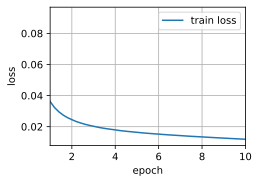

In [8]:
# ============================================================
# GloVe 训练函数
# ============================================================

def train_glove(net, data_iter, lr, num_epochs, device=d2l.try_gpu()):
    """
    训练 GloVe 词嵌入模型
    """
    optimizer = torch.optim.Adam(net.parameters(), lr=lr)
    net = net.to(device)
    
    animator = d2l.Animator(xlabel='epoch', ylabel='loss',
                            xlim=[1, num_epochs],
                            legend=['train loss'])
    
    metric = d2l.Accumulator(2)
    
    for epoch in range(num_epochs):
        timer = d2l.Timer()
        num_batches = len(data_iter)
        
        for i, batch in enumerate(data_iter):
            word_i, word_j, targets, weights = [x.to(device) for x in batch]
            
            optimizer.zero_grad()
            predictions = net(word_i, word_j)
            loss = criterion(predictions, targets, weights)
            loss.backward()
            optimizer.step()
            
            # 梯度裁剪
            torch.nn.utils.clip_grad_norm_(net.parameters(), max_norm=1.0)
            
            with torch.no_grad():
                metric.add(loss.item() * word_i.shape[0], word_i.shape[0])
            
            if (i + 1) % (num_batches // 5) == 0 or i == num_batches - 1:
                animator.add(epoch + (i + 1) / num_batches,
                             (metric[0] / metric[1],))
    
    print(f'loss {metric[0] / metric[1]:.3f}, '
          f'{metric[1] / timer.stop():.1f} pairs/sec on {str(device)}')

# ============================================================
# 开始训练
# ============================================================
lr = 0.001
num_epochs = 10

print(f"开始训练 GloVe 模型...")
print(f"学习率: {lr}")
print(f"训练轮数: {num_epochs}")
print(f"训练样本数: {len(glove_dataset)}")
print(f"总批次数: {len(glove_dataloader)}")

train_glove(glove_model, glove_dataloader, lr, num_epochs)

## 第八步：词相似度查询

In [ ]:
# ============================================================
# 词相似度查询函数（优化版）
# ============================================================

def get_similar_tokens_glove(query_token, k, model, vocab):
    """
    查找与查询词最相似的 k 个词（GloVe 版本）
    
    相似度计算：使用余弦相似度
    
    优化：确保计算在 GPU 上进行
    """
    # 检查词是否存在
    try:
        query_idx = vocab[query_token]
    except KeyError:
        print(f"警告: 词 '{query_token}' 不在词表中")
        return []
    
    # 获取词向量
    W = model.get_embeddings()
    
    # 检查设备并确保在同一设备上计算
    device = W.device
    x = W[query_idx]  # 查询词向量
    
    # 计算余弦相似度（GPU 加速）
    # 公式: cos(θ) = (W · x) / (||W|| × ||x||)
    numerator = torch.mv(W, x)  # 矩阵-向量乘法，GPU 上很快
    denominator = torch.sqrt(torch.sum(W * W, dim=1) * torch.sum(x * x) + 1e-9)
    cos = numerator / denominator
    
    # 找出最相似的 k+1 个词（+1 因为包含查询词自己）
    topk_values, topk_indices = torch.topk(cos, k=k+1)
    
    # 转到 CPU 进行打印（只在需要时转换）
    topk_indices_cpu = topk_indices.cpu().numpy().astype('int32')
    cos_cpu = cos.cpu()
    
    print(f"与 '{query_token}' 最相似的 {k} 个词:")
    # 跳过第一个（查询词自己）
    for i in topk_indices_cpu[1:]:
        print(f'  cosine sim={float(cos_cpu[i]):.3f}: {vocab.to_tokens(i)}')
    
    return [(vocab.to_tokens(i), float(cos_cpu[i])) for i in topk_indices_cpu[1:]]


# ============================================================
# 测试词相似度查询
# ============================================================
import time

print("=" * 50)
start = time.time()
result1 = get_similar_tokens_glove('chip', 5, glove_model, vocab)
print(f"  耗时: {time.time() - start:.3f}秒")

print("\n" + "=" * 50)
start = time.time()
result2 = get_similar_tokens_glove('year', 5, glove_model, vocab)
print(f"  耗时: {time.time() - start:.3f}秒")

print("\n" + "=" * 50)
start = time.time()
result3 = get_similar_tokens_glove('company', 5, glove_model, vocab)
print(f"  耗时: {time.time() - start:.3f}秒")

与 'chip' 最相似的 5 个词:
  cosine sim=0.894: microprocessor
  cosine sim=0.877: 300-day
  cosine sim=0.875: prebon
  cosine sim=0.872: a$
  cosine sim=0.871: s
  耗时: 0.003秒

与 'year' 最相似的 5 个词:
  cosine sim=0.910: earlier
  cosine sim=0.883: rose
  cosine sim=0.867: from
  cosine sim=0.866: sept.
  cosine sim=0.864: billion
  耗时: 0.002秒

与 'company' 最相似的 5 个词:
  cosine sim=0.841: expects
  cosine sim=0.836: also
  cosine sim=0.832: end
  cosine sim=0.825: the
  cosine sim=0.823: of
  耗时: 0.002秒


## 第九步：词向量类比

In [ ]:
# ============================================================
# 词类比任务（Word Analogy）
# ============================================================

def word_analogy_glove(w1, w2, w3, model, vocab, k=5):
    """
    词类比任务
    
    vec(w1) - vec(w2) + vec(w3) ≈ vec(w4)
    """
    # 使用 try-except 快速检查词是否存在（避免遍历词表）
    try:
        idx1, idx2, idx3 = vocab[w1], vocab[w2], vocab[w3]
    except KeyError as e:
        print(f"警告: 词 {e} 不在词表中")
        return None
    
    # 获取词向量（确保在同一个设备上）
    W = model.get_embeddings()
    
    # 如果 W 在 GPU，x 也会在 GPU，计算会很快
    x = W[idx1] - W[idx2] + W[idx3]
    
    # 计算余弦相似度
    # 公式: cos(θ) = (W · x) / (||W|| × ||x||)
    numerator = torch.mv(W, x)
    denominator = torch.sqrt(torch.sum(W * W, dim=1) * torch.sum(x * x) + 1e-9)
    cos = numerator / denominator
    
    # 排除输入词
    exclude_indices = {idx1, idx2, idx3}
    mask = torch.ones(len(vocab), dtype=torch.bool)
    for idx in exclude_indices:
        mask[idx] = False
    
    # 应用掩码
    cos_masked = cos.clone()
    cos_masked[~mask] = float('-inf')
    
    # 找出前 k 个
    topk = torch.topk(cos_masked, k=k)[1].cpu().numpy().astype('int32')
    
    print(f"{w1} - {w2} + {w3} = ?")
    for i, idx in enumerate(topk, 1):
        print(f"  {i}. {vocab.to_tokens(idx)} (相似度: {float(cos[idx]):.3f})")
    
    return [vocab.to_tokens(idx) for idx in topk]


# ============================================================
# 测试词类比
# ============================================================
print("=" * 50)
print("测试 1: chip - intel + company = ?")
# chip (芯片) - intel (公司) + company (公司) ≈ 其他芯片公司
result = word_analogy_glove('chip', 'intel', 'company', glove_model, vocab, k=5)

print("\n" + "=" * 50)
print("测试 2: company - stock + bank = ? (如果这些词在词表中)")
# 尝试另一个类比
try:
    result = word_analogy_glove('company', 'stock', 'bank', glove_model, vocab, k=3)
except Exception as e:
    print(f"测试失败（某些词可能不在词表中）: {e}")

测试 1: chip - intel + company = ?
chip - intel + company = ?
  1. expects (相似度: 0.817)
  2. end (相似度: 0.808)
  3. also (相似度: 0.800)
  4. had (相似度: 0.795)
  5. a (相似度: 0.788)

测试 2: company - stock + bank = ? (如果这些词在词表中)
company - stock + bank = ?
  1. group (相似度: 0.640)
  2. portion (相似度: 0.613)
  3. ibm (相似度: 0.604)


## 第十步：可视化词向量

开始可视化词向量...
待可视化词数: 23
找到 23/23 个有效词


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 31532 (\N{CJK UNIFIED IDEOGRAPH-7B2C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 20108 (\N{CJK UNIFIED IDEOGRAPH-4E8C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 20027 (\N{CJK UNIFIED IDEOGRAPH-4E3B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 25104 (\N{CJK UNIFIED IDEOGRAPH-6210}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  fig.canvas

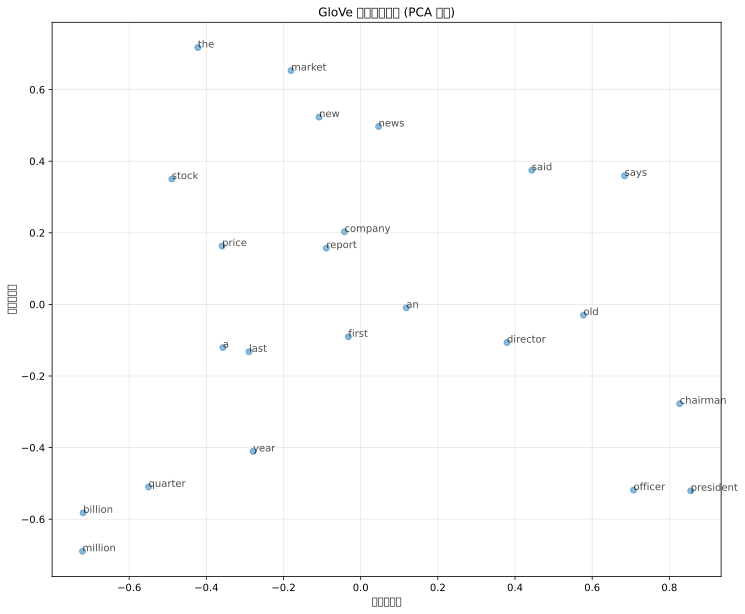

PCA 解释方差比: [0.20468424 0.1489278 ]
累计解释方差比: 0.354
可视化完成，总耗时: 0.204秒


In [ ]:
# ============================================================
# 词向量可视化（PCA 降维）- 优化版
# ============================================================

def visualize_embeddings(model, vocab, words_to_plot):
    """
    可视化词向量（使用 PCA 降维）
    
    优化：快速过滤有效词，避免慢速词表查询
    """
    from sklearn.decomposition import PCA
    import matplotlib.pyplot as plt
    
    # 快速获取词向量（避免重复调用 get_embeddings）
    W = model.get_embeddings().cpu().numpy()
    
    # 优化：使用 try-except 批量获取有效词索引
    # 避免慢速的 "word in vocab" 检查
    valid_indices = []
    valid_words = []
    for word in words_to_plot:
        try:
            idx = vocab[word]
            valid_indices.append(idx)
            valid_words.append(word)
        except KeyError:
            # 词不在词表中，跳过
            pass
    
    if len(valid_indices) == 0:
        print("警告: 没有找到有效的词进行可视化")
        return
    
    print(f"找到 {len(valid_words)}/{len(words_to_plot)} 个有效词")
    
    # 获取这些词的向量
    word_vectors = W[valid_indices]
    
    # PCA 降维
    pca = PCA(n_components=2)
    vectors_2d = pca.fit_transform(word_vectors)
    
    # 绘制散点图
    plt.figure(figsize=(12, 10))
    plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], alpha=0.5)
    
    # 添加标注（只标注有效词）
    for i, word in enumerate(valid_words):
        plt.annotate(word, (vectors_2d[i, 0], vectors_2d[i, 1]),
                    fontsize=10, alpha=0.7)
    
    plt.title("GloVe 词向量可视化 (PCA 降维)")
    plt.xlabel("第一主成分")
    plt.ylabel("第二主成分")
    plt.grid(True, alpha=0.3)
    plt.show()
    
    print(f"PCA 解释方差比: {pca.explained_variance_ratio_}")
    print(f"累计解释方差比: {pca.explained_variance_ratio_.sum():.3f}")


# ============================================================
# 可视化高频词
# ============================================================
import time

# 选择 PTB 数据集中可能存在的词
words_to_visualize = [
    'the', 'a', 'an',
    'company', 'stock', 'market', 'price',
    'million', 'billion', 'year', 'quarter',
    'president', 'chairman', 'director', 'officer',
    'said', 'says', 'report', 'news',
    'new', 'old', 'first', 'last',
]

print("开始可视化词向量...")
print(f"待可视化词数: {len(words_to_visualize)}")

start = time.time()
visualize_embeddings(glove_model, vocab, words_to_visualize)
print(f"可视化完成，总耗时: {time.time() - start:.3f}秒")